**1. Imports & Setup**

In [97]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

**2. Load Data**

In [98]:
df = pd.read_csv("Data_6Months.csv") 

print(df.shape)
df.head()

(348151, 27)


,Account_number,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disbursal_date,disb_amt,tenor,roi,emi,cibil_score,residence_city,residence_state,pincode,emp_type,industry_type,total_work_exp_months,final_veri_monthly_income,writeoff_date,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,Pmt_amount,month_end_date
0,1.151000e+11,0.0,4380.0,NCL,PL_SELF,27/01/09 00:00,105000.0,24.0,32.380001,6035.0,NaN,NaN,NaN,380023.0,NaN,NaN,NaN,NaN,01-Jun-11,5884.0,146.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
1,1.152000e+11,0.0,0.0,NCL,PL_SELF,12/09/08 00:00,200000.0,20.0,22.969999,12065.0,NaN,NaN,NaN,380023.0,NaN,NaN,NaN,NaN,01-Sep-10,11844.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
2,1.152000e+11,0.0,4046.0,NCL,PL_SELF,28/12/08 00:00,650000.0,36.0,22.219999,24993.0,NaN,NaN,NaN,380015.0,NaN,NaN,NaN,NaN,01-May-12,24464.0,148.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
3,2.152000e+11,760.0,4686.0,NCL,PL_SELF,24/03/08 00:00,155000.0,24.0,30.129999,8783.0,NaN,NaN,NaN,560050.0,NaN,NaN,NaN,NaN,01-Aug-10,8560.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
4,2.152000e+11,10.0,4015.0,NCL,PL_SELF,12/02/09 00:00,150000.0,36.0,32.759998,6542.0,NaN,NaN,NaN,560050.0,NaN,NaN,NaN,NaN,01-Jun-12,10.0,147.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28


**3. Data Cleaning**

**Date Parsing**

In [99]:
print(df['disbursal_date'].head(10).tolist())

['27/01/09 00:00', '12/09/08 00:00', '28/12/08 00:00', '24/03/08 00:00', '12/02/09 00:00', '29/08/09 00:00', '13/12/07 00:00', '27/01/09 00:00', '25/04/08 00:00', '30/04/08 00:00']


In [100]:
print(df['disbursal_date'].dtype)

object


In [101]:
df['disbursal_date'] = pd.to_datetime(
    df['disbursal_date'],
    format='%d/%m/%y %H:%M',
    errors='coerce'
)

In [102]:
print(df['disbursal_date'].head(10))
print(df['disbursal_date'].isna().sum())

0   2009-01-27
1   2008-09-12
2   2008-12-28
3   2008-03-24
4   2009-02-12
5   2009-08-29
6   2007-12-13
7   2009-01-27
8   2008-04-25
9   2008-04-30
Name: disbursal_date, dtype: datetime64[ns]
149


In [106]:

df['writeoff_date'] = pd.to_datetime(
    df['writeoff_date'],
    format='%d-%b-%y',
    errors='coerce'
)


In [104]:
df['month_end_date'] = pd.to_datetime(
    df['month_end_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

In [105]:
print(df['month_end_date'].head(10).tolist())
print(df['month_end_date'].dtype)

[Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00'), Timestamp('2023-02-28 00:00:00')]
datetime64[ns]


In [107]:
print(df.head(10))

   Account_number  Principal_outstanding  dpd_days dpd_bucket prod_name  \
0    1.151000e+11                    0.0    4380.0        NCL   PL_SELF   
1    1.152000e+11                    0.0       0.0        NCL   PL_SELF   
2    1.152000e+11                    0.0    4046.0        NCL   PL_SELF   
3    2.152000e+11                  760.0    4686.0        NCL   PL_SELF   
4    2.152000e+11                   10.0    4015.0        NCL   PL_SELF   
5    2.152000e+11                   37.0    3802.0        NCL   PL_SELF   
6    6.151000e+11                    0.0    4442.0        NCL   PL_SELF   
7    6.151000e+11                    0.0    4380.0        NCL   PL_SELF   
8    6.152000e+11                    0.0       0.0        NCL   PL_SELF   
9    6.152000e+11                    0.0       0.0        NCL   PL_SELF   

  disbursal_date  disb_amt  tenor        roi      emi  cibil_score  \
0     2009-01-27  105000.0   24.0  32.380001   6035.0          NaN   
1     2008-09-12  200000.0   20.0 

In [108]:
print(df['Account_number'].iloc[0])

115100003230.0


**Missing Value**

In [134]:
missing = df.isnull().sum().sort_values(ascending=False)
#print(missing)
#print("##############################################################")
missing_pct = (missing / len(df)) * 100
#print(missing_pct)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_df.head(20)

,missing_count,missing_pct
writeoff_date,153,0.043946
disbursal_date,149,0.042798
Account_number,0,0.000000
industry_type,0,0.000000
paid_flag,0,0.000000
month_end_date,0,0.000000
Pmt_amount,0,0.000000
total_outstanding,0,0.000000
final_dbr,0,0.000000
loan_program_type,0,0.000000


**Handle Missing**

In [135]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Numeric -> median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical -> mode
for col in cat_cols:
    mode_val = df[col].mode(dropna=True)
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val[0])

**Outlier Treatment**

In [113]:
def cap_outliers(col):
    q1 = col.quantile(0.01)
    q99 = col.quantile(0.99)
    return np.clip(col, q1, q99)

for col in num_cols:
    df[col] = cap_outliers(df[col])

**Target Variable**

In [114]:
df['paid_flag'] = np.where(df['Pmt_amount'] > 0, 1, 0)

**DATA QUALITY SUMMARY**

**4. EXPLORATORY DATA ANALYSIS**

**Account Distribution**

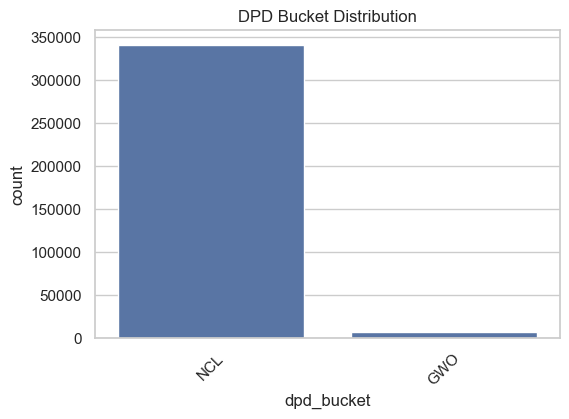

In [115]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='dpd_bucket')
plt.title("DPD Bucket Distribution")
plt.xticks(rotation=45)
plt.show()

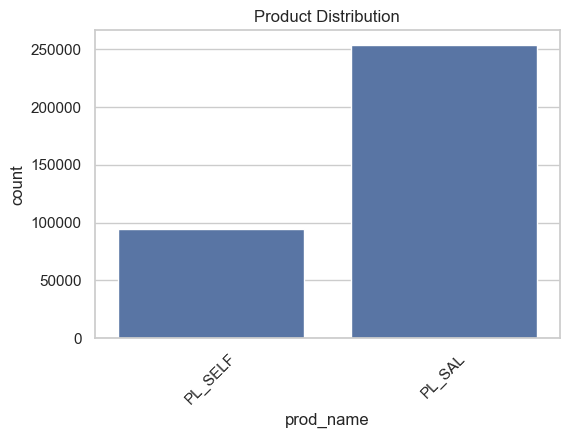

In [116]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='prod_name')
plt.title("Product Distribution")
plt.xticks(rotation=45)
plt.show()

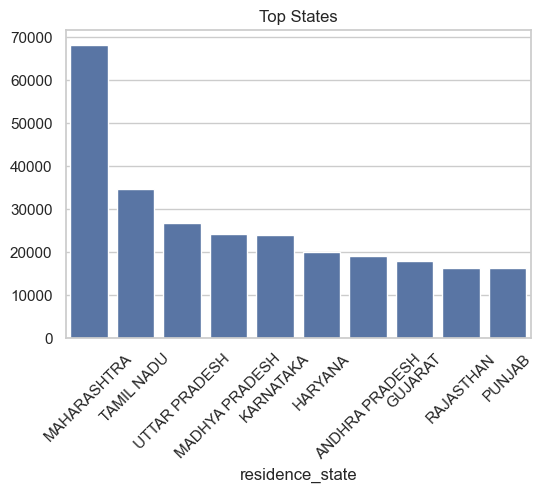

In [117]:
top_states = df['residence_state'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top States")
plt.xticks(rotation=45)
plt.show()

**Payment Trends**

In [118]:
monthly = df.groupby('month_end_date').agg({
    'Pmt_amount': 'sum',
    'Account_number': pd.Series.nunique
}).rename(columns={'Account_number': 'unique_payers'}).reset_index()

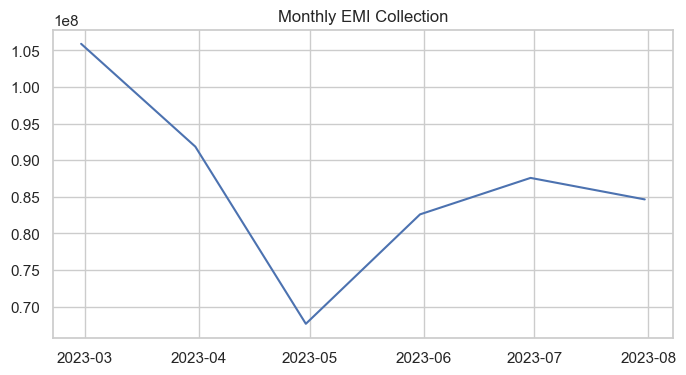

In [119]:
plt.figure(figsize=(8,4))
plt.plot(monthly['month_end_date'], monthly['Pmt_amount'])
plt.title("Monthly EMI Collection")
plt.show()

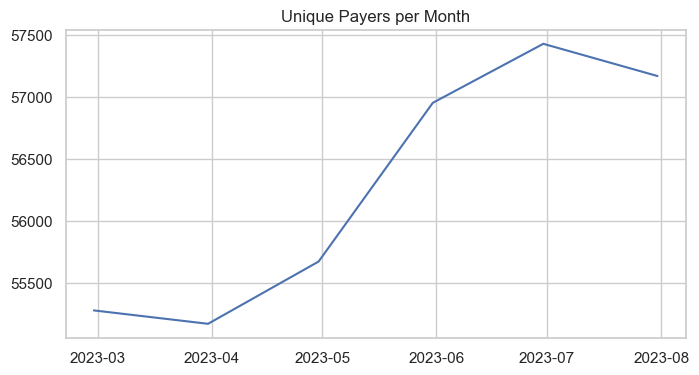

In [120]:
plt.figure(figsize=(8,4))
plt.plot(monthly['month_end_date'], monthly['unique_payers'])
plt.title("Unique Payers per Month")
plt.show()

Active vs Delinquent

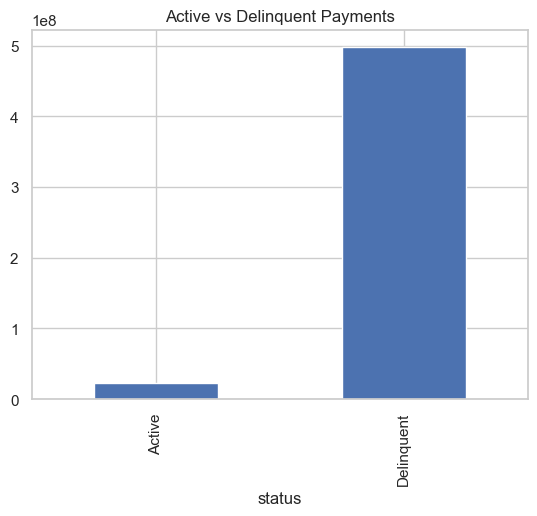

In [121]:
df['status'] = np.where(df['dpd_days'] > 30, 'Delinquent', 'Active')

status_df = df.groupby('status')['Pmt_amount'].sum()

status_df.plot(kind='bar', title='Active vs Delinquent Payments')
plt.show()

**5. MODELING**

**Feature Selection**

In [122]:
drop_cols = [
    'Account_number',
    'disbursal_date',
    'writeoff_date',
    'month_end_date',
    'Pmt_amount'  # IMPORTANT: leakage
]

df_model = df.drop(columns=drop_cols)

In [123]:
df_model

,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disb_amt,tenor,roi,emi,cibil_score,residence_city,residence_state,pincode,emp_type,industry_type,total_work_exp_months,final_veri_monthly_income,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,paid_flag,status
0,0.00,4076.5,NCL,PL_SELF,105000.0,25.0,32.380001,6035.0,768.0,CHENNAI,MAHARASHTRA,380023.0,SALARIED,GOVERNMENT,78.0,15518.75,5884.00,146.0,MASS CHANNELS,STANDARD,51.80,-,0,Delinquent
1,0.00,0.0,NCL,PL_SELF,200000.0,25.0,22.969999,12065.0,768.0,CHENNAI,MAHARASHTRA,380023.0,SALARIED,GOVERNMENT,78.0,15518.75,11844.00,149.0,MASS CHANNELS,STANDARD,51.80,-,0,Active
2,0.00,4046.0,NCL,PL_SELF,650000.0,36.0,22.219999,24993.0,768.0,CHENNAI,MAHARASHTRA,380015.0,SALARIED,GOVERNMENT,78.0,15518.75,24464.00,148.0,MASS CHANNELS,STANDARD,51.80,-,0,Delinquent
3,760.00,4076.5,NCL,PL_SELF,155000.0,25.0,30.129999,8783.0,768.0,CHENNAI,MAHARASHTRA,560050.0,SALARIED,GOVERNMENT,78.0,15518.75,8560.00,149.0,MASS CHANNELS,STANDARD,51.80,-,0,Delinquent
4,10.00,4015.0,NCL,PL_SELF,150000.0,36.0,32.759998,6542.0,768.0,CHENNAI,MAHARASHTRA,560050.0,SALARIED,GOVERNMENT,78.0,15518.75,34.00,147.0,MASS CHANNELS,STANDARD,51.80,-,0,Delinquent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348146,262127.19,1029.0,NCL,PL_SAL,249648.0,61.0,29.690000,8030.0,744.0,HATHRAS,UTTAR PRADESH,442401.0,SALARIED,GOVERNMENT,78.0,14791.40,262920.19,148.0,RO OWN SOURCING,PL TOP UP,43.55,-,0,Delinquent
348147,42955.48,696.0,NCL,PL_SAL,145520.0,25.0,35.500000,11549.0,-1.0,HATHRAS,UTTAR PRADESH,442401.0,SALARIED,GOVERNMENT,78.0,12440.45,42955.48,149.0,RO OWN SOURCING,PL INCOME BASED,49.82,-,0,Delinquent
348148,167823.96,423.0,NCL,PL_SAL,174868.0,61.0,35.500000,6263.0,720.0,HATHRAS,UTTAR PRADESH,442401.0,SALARIED,GOVERNMENT,144.0,20776.60,171500.86,146.0,PARIVAR DOST,PL INCOME BASED,64.99,-,0,Delinquent
348149,681585.76,178.0,NCL,PL_SELF,753838.0,37.0,27.000000,30776.0,773.0,HATHRAS,UTTAR PRADESH,442401.0,SELFEMPLOYED,CHEMICALS,57.0,15518.75,681585.76,149.0,PARIVAR DOST,PL SURROGATE,51.80,942589.2,0,Delinquent


**Encode Categorical**

In [124]:
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

**Train-Test Split**

X = df_model.drop('paid_flag', axis=1)
y = df_model['paid_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scaling (for Logistic)**

In [126]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [127]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_proba = lr.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Logistic ROC-AUC:", roc_auc)

Logistic ROC-AUC: 0.8133723589084036


**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict_proba(X_test)[:,1]

roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print("Decision Tree ROC-AUC:", roc_auc_dt)

**Feature Importance**

In [129]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

dpd_days                 0.622118
Principal_outstanding    0.183442
total_outstanding        0.115543
dpd_days_wo              0.041774
total_work_exp_months    0.017932
gwo_amt                  0.015363
residence_state          0.002565
disb_amt                 0.001071
final_dbr                0.000156
residence_city           0.000035
dtype: float64

**INSIGHTS**

**CONCLUSION & NEXT STEPS**

In [ ]:
1.Model can identify high-risk customers
2.Use for prioritizing collections
3.Improve with:
    i)time-series features
    ii)behavioral data
    iii)advanced models (XGBoost)